# Unsupervised Learning
- 
- 

- Unsupervised Learning is the type of ML in which:
    - Models learn from Unlabelled data
    - by finding hidden patterns or structures or groupings

Types:
1. Clustering - find similar data and group it
2. Association Learning - find similar data from within the data
3. Dimensionality reduction - reduce the number of features while retaining the essential information

#### Clustering
- a technique to organize data into groups or clusters based on some hidden similarity/patterns
- Goals are:
    - to find the natural grouping in data
    - simplify data by removing extra features, columns

- **Hard Clustering** and **Soft Clustering**
    - each data point in exactly a single cluster - Hard
    - or can be part of other clusters too, overlaps too - Soft

Algorithms used:
1. K-Means Clustering
2. Hierarchial Clustering
3. DBSCAN (Density Based Special Clustering of Application Noise)

### K-means Clustering
- 
- Resource 1 - https://neptune.ai/blog/k-means-clustering
- Resource 2 - https://www.pinecone.io/learn/k-means-clustering

Steps to K-Means Clustering:

- you will have data
- you choose some K points i.e. number of clusters

1. **Initialization**:
    - Randomly select K points as initial cluster centroids.
    - You select 3 random points in the data or use **kmeans++** and initialize 3 points as spread out as possible
2. **Assignment**:
    - Assign each data point to the nearest centroid.
    - Calculate distance of each data point to each of the cluster centroids and assign them to the nearest centroid
    - Distance is calculated using various metrics like:
        - euclidean, manhattan, minkowski
3. **Update**:
    - Recalculate the centroids by averaging the points in each cluster.
    - Centroid - an average of the points in a group
4. **Convergence**: Repeat assignment and update steps until centroids stabilize.

Distance Metrics:

[Distance Metrics](https://www.geeksforgeeks.org/machine-learning/clustering-distance-measures/)

1. Euclidean:
    - Straight-line distance between 2 points
2. Manhattan distance:
    - total of the absolute differences between their Cartesian coordinates
    - sometimes referred to as the *L1 distance* or *city block* distance
3. 

Illustration from blog - https://vas3k.com/blog/machine_learning/index.html

Code implementation - 

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

In [18]:
data = load_iris()
df = pd.DataFrame(data.data, columns= data.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [19]:
model = KMeans(n_clusters= 3, init= 'random', random_state= 42)

model

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'random'
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [20]:
df['KClustering'] = model.fit_predict(df)
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),KClustering
23,5.1,3.3,1.7,0.5,0
126,6.2,2.8,4.8,1.8,1
80,5.5,2.4,3.8,1.1,1
134,6.1,2.6,5.6,1.4,2
5,5.4,3.9,1.7,0.4,0


In [ ]:
model.inertia_ # how far spread out the clusters

78.851441426146

- Inertia is the sum of squared distances of each data point to its closest cluster center.
- It's essentially the total squared error of the clustering.
- 

#### Visualize data vs results

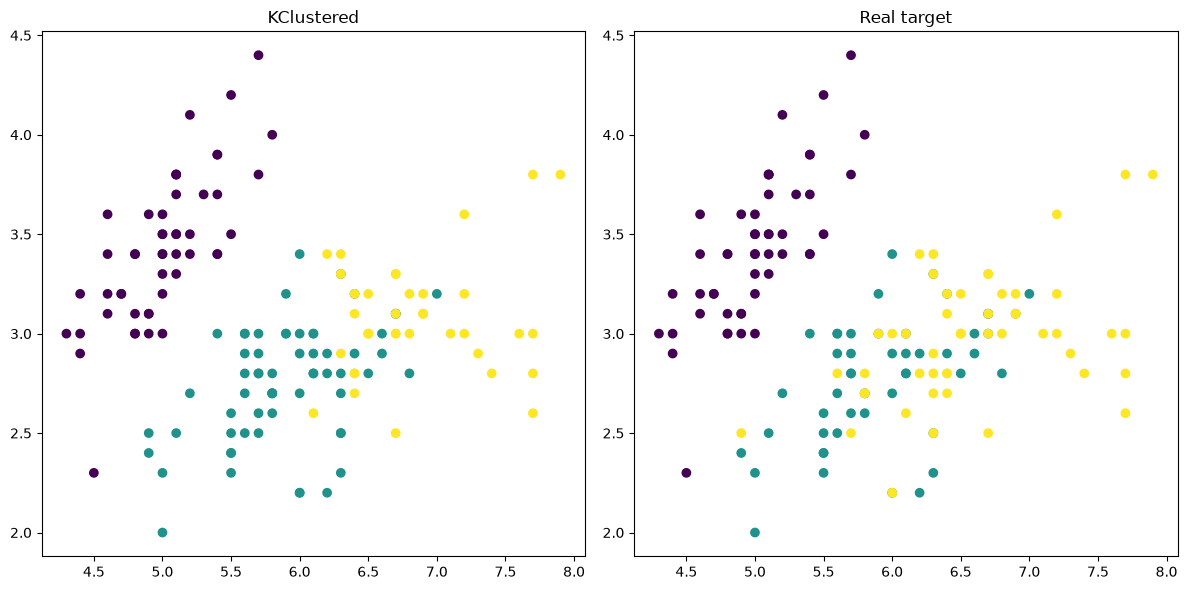

In [22]:
fig, ax = plt.subplots(1, 2, figsize= (12, 6))

ax[0].scatter(df['sepal length (cm)'], df['sepal width (cm)'], c= df['KClustering'])
ax[0].set_title('KClustered')

ax[1].scatter(df['sepal length (cm)'], df['sepal width (cm)'], c= data.target)
ax[1].set_title('Real target')

plt.tight_layout()
plt.show()


### More about K Means
- Initialization:
    - Centroid initialization is the first and crucial step in clustering algorithms like K-Means.
    - Poor initialization can lead to overlapping clusters, empty clusters, or slow convergence.
    - The K-Means++ method:
        - improves this step by strategically **spreading out** initial centroids instead of picking them purely at random.
        - keep them as far as possible from each other
        - the algorithm is more computationally expensive
        - but leads to faster convergence
- Convergence:
    - when all the centroids are at the optimal position

### Optimal value of K
- you don't know how many clusters there would be
- we use a couple of methods:
    - ELBOW Method

    - we use the WCSS (Within-Cluster Sum of Squares) error against the values of K
    - whereever there is an inflection point, that is our optional value of K
    

In [24]:
errors = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters= k, random_state= 42)
    kmeans.fit(df)
    errors.append(kmeans.inertia_)

errors

[768.4105999999999,
 177.7202495543672,
 78.851441426146,
 59.34876557610241,
 46.985061122661115,
 39.57886631746632,
 35.226026106246685,
 31.241030758714974,
 29.402220624404844,
 27.88959403341757]

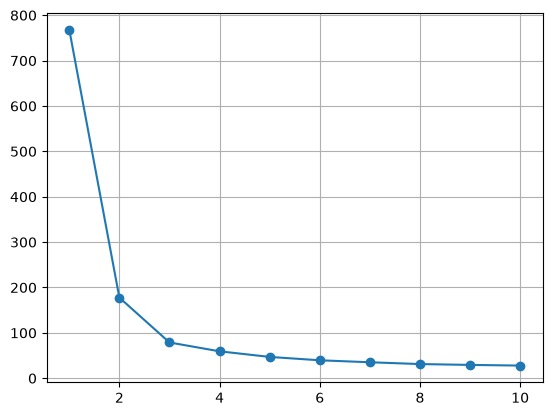

In [26]:
plt.plot(range(1, 11), errors, marker= 'o')
plt.grid()
plt.show()